This code is created to run assimilations with all UMRB stations and then without all UMRB stations. A difference map is then made to compare the differences between the two.

In [1]:
import sys
import os as os

import geopandas as gpd
import numpy as np
from numpy.polynomial import Polynomial
import psycopg2
from netCDF4 import Dataset

from tqdm import tqdm
from multiprocessing import Pool
import statsmodels.api as sm
from scipy import stats
# from scipy import optimize

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature as cfNEF

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
#import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D

import rasterio
import xarray as xr

import random
import subprocess
import netCDF4
import shutil

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
import seaborn as sns
from scipy.stats import gaussian_kde

import pathlib
import glob
import pandas as pd

from sklearn.metrics import r2_score

Create a list of all the UMRB station_id's

In [2]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

Run assimilation with all UMRB Stations included if Carrie has not aready run one for the date (Baseline)

In [7]:
# Inputs for code:
folder_name = "snodas_assim_20231228_with_umrb_updated_base"
start_date = "2023122712" # These are the numbers within the shapefile like shown in shapefile name above
end_date = "2023122812" # These are the numbers within the shapefile like shown in shapefile name above


# Enter command you want to run (Look at commands in Greg's Examples, this command uses assigned IDW creteria to create new nudging layer)
# Also make sure IDW parameters are correct 
cmd = f"python ./snodas_idw.py -k -i 3 50 2 2 200 {start_date} {end_date} central -f ../Test_Runs/{folder_name}" #Careful with the US, West, etc. part in command

# Run Greg's code using the above inputs and chosen command in cmd line
subprocess.run(cmd, capture_output=True)

CompletedProcess(args='python ./snodas_idw.py -k -i 3 50 2 2 200 2023122712 2023122812 central -f ../Test_Runs/snodas_assim_20231228_with_umrb_updated_base', returncode=0, stdout=b'', stderr=b'2024-07-16 15:57:29 Mountain Daylight Time RTI-106712 snodas_idw.py[6552-MainThread]: WARNING: No [-b, --no_database] argument provided, but assumed because this system appears to be non-operational.\r\n2024-07-16 15:57:29 Mountain Daylight Time RTI-106712 snodas_idw.py[6552-MainThread]: WARNING: Unable to create output directory ../Test_Runs/snodas_assim_20231228_with_umrb_updated_base. Will use c:\\Repos\\umrb-snodas\\src\r\n2024-07-16 15:57:29 Mountain Daylight Time RTI-106712 snodas_idw.py[6552-MainThread]: INFO: Input shapefile path is ../Test_Runs/snodas_assim_20231228_with_umrb_updated_base\\ssm1054_md_based_2023122712_2023122812_central.shp\r\n2024-07-16 15:57:32 Mountain Daylight Time RTI-106712 snodas_idw.py[6552-MainThread]: INFO: Limiting MD_DENSITY and recalculating deltas for 35 sim

Run assimilation without any UMRB stations and create difference map

In [3]:
# Inputs for code:
net_CDF1_Path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_base_updated\ssm1054_2023122812.nc" # This file is the one comparison file (so use baseline netcdf output here)
net_CDF2_Path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated\ssm_process_region_2023122712_2023122812_swe_central.nc" # This is the file that creates the boundaries for the assimilation.
net_CDF_name_us = "ssm_process_region_2023122712_2023122812_swe_central.nc"
net_CDF_name = "ssm1054_2023122812.nc" # When changing to baseline output netCDF you still need to save with the name of original example run name!!
shapefile_name = "ssm1054_md_based_2023122712_2023122812_central.shp"

# Inputs for code:
folder_name = "snodas_assim_20231228_with_umrb_updated"
start_date = "2023122712" # These are the numbers within the shapefile like shown in shapefile name above
end_date = "2023122812" # These are the numbers within the shapefile like shown in shapefile name above

# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{shapefile_name}"
gdf = gpd.read_file(shapefile_path)

# Create new shapefile with no UMRB stations in it:
# Remove all rows where 'STATION_ID' is in UMRB_ID
gdf_2 = gdf[~gdf['STATION_ID'].isin(UMRB_ID)]

# Change folder and shapefile names for new assimilation (Need to change these as well!!!!)
folder_name = f"snodas_assim_20231228_NO_UMRB_updated"
shapefile_name = f"ssm1054_md_based_2023122712_2023122812_central0.shp" # Change shapefile name
net_CDF_name_us = f"ssm_process_region_2023122712_2023122812_swe_central0.nc" # Change processing region netCDF name

# Write new shapefile to new folder - had to save twice to get correct shapefile name - Ideas???
gdf_2.to_file(f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}")
gdf_2.to_file(f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{shapefile_name}")

# Copy netCDF's from orgignal folder to new folder (Need original netCDF's to run)
shutil.copy(net_CDF1_Path,f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{net_CDF_name}" )
shutil.copy(net_CDF2_Path,f"C:/Repos/umrb-snodas/Test_Runs/{folder_name}/{net_CDF_name_us}" )

# Enter command you want to run (Look at commands in Greg's Examples, this command uses assigned IDW creteria to create new nudging layer) 
cmd = f"python ./snodas_idw.py -k -i 3 50 2 2 200 {start_date} {end_date} central0 -f ../Test_Runs/{folder_name}" #Careful with the US, West, etc. part in command
    
# Run Greg's code using the above inputs and chosen command in cmd line
subprocess.run(cmd, capture_output=True)

CompletedProcess(args='python ./snodas_idw.py -k -i 3 50 2 2 200 2023122712 2023122812 central0 -f ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated', returncode=0, stdout=b'', stderr=b'2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: WARNING: No [-b, --no_database] argument provided, but assumed because this system appears to be non-operational.\r\n2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: WARNING: Unable to create output directory ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated. Will use c:\\Repos\\umrb-snodas\\src\r\n2024-07-16 09:08:06 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: INFO: Input shapefile path is ../Test_Runs/snodas_assim_20231228_NO_UMRB_updated\\ssm1054_md_based_2023122712_2023122812_central0.shp\r\n2024-07-16 09:08:11 Mountain Daylight Time RTI-106712 snodas_idw.py[6092-MainThread]: INFO: Limiting MD_DENSITY and recalculating deltas for 32 simulated (depth-based

The following code takes a netCDF file and overlays point data on it using a shapefile (Look at With UMRB here)

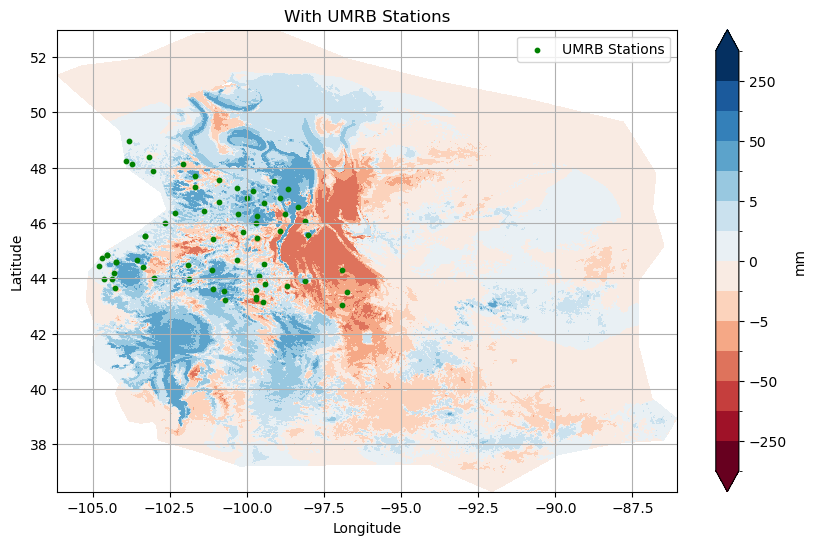

In [10]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated_base\ssm1054_snodas_idw_test_2023122812_central.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000 to get in mm
variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap


bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
contour = plt.contourf(lons, lats, variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both')
plt.colorbar(label='mm')
plt.title('With UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10)

plt.legend()
plt.grid(True)
plt.show()




Creates map of Assimilation like above (Use non-UMRB Assimilation here)

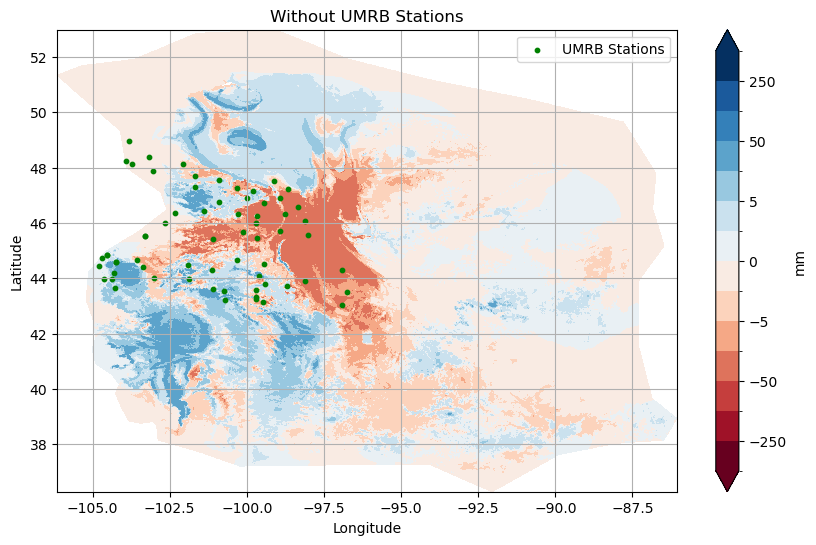

In [11]:
# Step 1: Read the netCDF file
nc_file = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_NO_UMRB_updated\ssm1054_snodas_idw_test_2023122812_central0.nc"
nc_data = netCDF4.Dataset(nc_file)
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Multiply the data by 1000
new_variable_data = nc_data.variables["Data"][:] * 1000

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
contour = plt.contourf(lons, lats, new_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both')
plt.colorbar(label='mm')
plt.title('Without UMRB Stations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10)

plt.legend()
plt.grid(True)
plt.show()

Create difference data and difference map comparing with and without UMRB

In [12]:
difference_variable_data = (variable_data - new_variable_data)

difference_variable_data

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-99999.0)

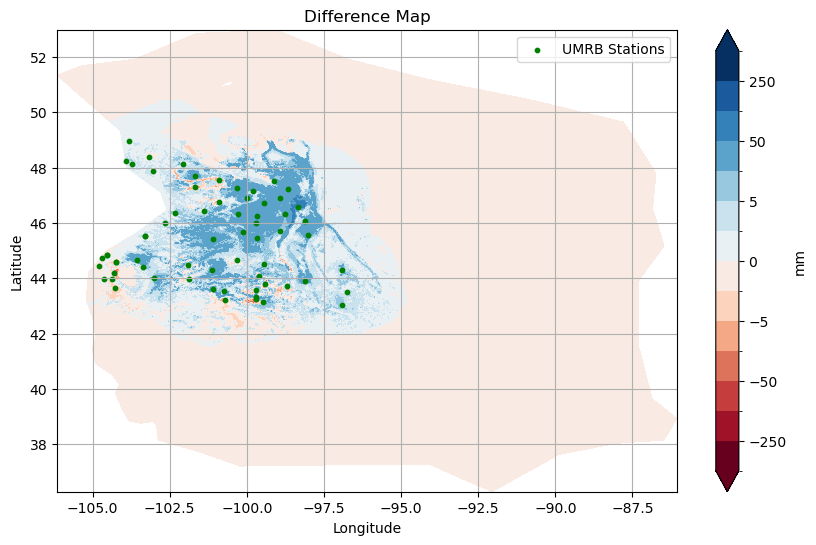

In [13]:
# Step 1: Read the netCDF file
lats = nc_data.variables["lat"][:]
lons = nc_data.variables["lon"][:]

# Step 2: Read the shapefile
# Load the shapefile: This is the shapefile containing the point data of all gage stations
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_28_23_Assimilations_updated\snodas_assim_20231228_with_umrb_updated\ssm1054_md_based_2023122712_2023122812_central.shp"
gdf = gpd.read_file(shapefile_path)

# Only keep the UMRB Stations
filtered_gdf = gdf[gdf['STATION_ID'].isin(UMRB_ID)]

bounds = [-500, -250, -100, -50, -10, -5, -1, 0, 1, 5, 10, 50, 100, 250, 500]

# Define custom colormap from dark red to dark blue
cmap = plt.get_cmap('RdBu')

# Create a colormap normalization instance
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Example of using the custom colormap and bounds
plt.figure(figsize=(10, 6))
contour = plt.contourf(lons, lats, difference_variable_data, cmap=cmap, norm=norm, levels=bounds, extend='both')
plt.colorbar(label='mm')
plt.title('Difference Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Overlay the shapefile points
plt.scatter(filtered_gdf.geometry.x, filtered_gdf.geometry.y, color='green', label='UMRB Stations', s=10)

plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Define the target latitude and longitude
target_lat = 46  # Replace with your target latitude
target_lon = -92.5  # Replace with your target longitude

# Find the index of the nearest latitude and longitude
lat_idx = (np.abs(lats - target_lat)).argmin()
lon_idx = (np.abs(lons - target_lon)).argmin()

# Extract the value from the difference data at the target lat/lon
value = new_variable_data[lat_idx, lon_idx]

print(f"Value at ({target_lat}, {target_lon}): {value}")

Value at (46, -92.5): -0.13761501759290695


Wanted to save the newly created shapefile with just the UMRB_Stations (might want to do this with other assimilations to use in ArcGIS Pro)

In [20]:
# Save the filtered GeoDataFrame as a shapefile
output_shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\UMRB_Stations_12_11_22.shp"
filtered_gdf.to_file(output_shapefile_path)

Looking at statistics of netCDF files

In [17]:
# Compute basic statistics for netCDF files 
data_min = np.min(variable_data)
data_max = np.max(variable_data)
data_mean = np.mean(variable_data)
data_std = np.std(variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)


Minimum value: -37.917669862508774
Maximum value: 36.41462326049805
Mean value: -0.7353154617091539
Standard deviation: 5.170142405442958


In [18]:
# Compute basic statistics for netCDF files 
data_min = np.min(new_variable_data)
data_max = np.max(new_variable_data)
data_mean = np.mean(new_variable_data)
data_std = np.std(new_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -37.917666137218475
Maximum value: 32.362956553697586
Mean value: -1.2395038758053063
Standard deviation: 5.406056231569338


In [16]:
# Compute basic statistics for netCDF files 
data_min = np.min(difference_variable_data)
data_max = np.max(difference_variable_data)
data_mean = np.mean(difference_variable_data)
data_std = np.std(difference_variable_data)

print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)

Minimum value: -37.29965165257454
Maximum value: 58.42896178364754
Mean value: 0.5041884140961528
Standard deviation: 3.4031403601146475


Look at difference data without the zero values to see how much values deviate from eachother (I changed to absolut value!!!!)

In [23]:
# Remove all zero values from difference data

# Converting the data to NumPy arrays
difference_variable_data = np.array(difference_variable_data)

# Create array without any zero and -99999 values
non_zero_difference_data = np.abs(difference_variable_data[(difference_variable_data != 0) & (difference_variable_data != -99999)])

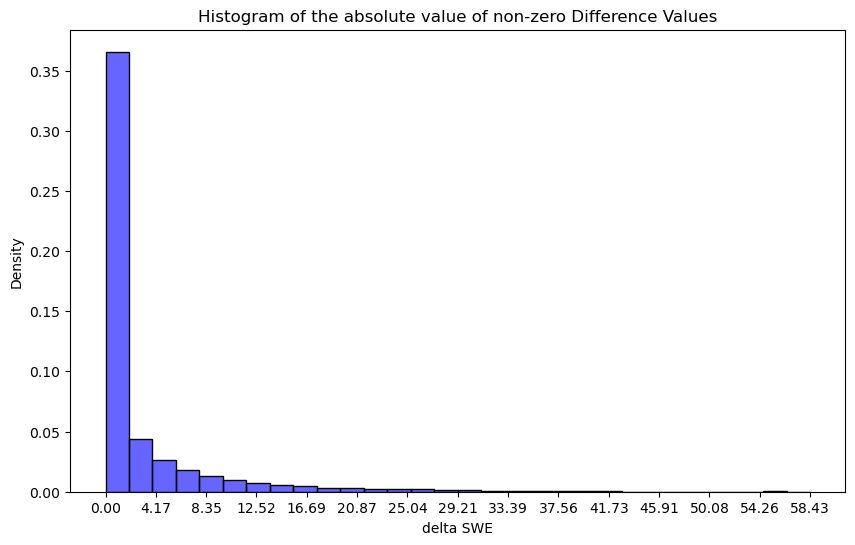

In [25]:
#create histogram and PDF for Without UMRB station assimilation

# Step 4: Flatten the variable_data to 1D array for histogram
flat_data = non_zero_difference_data.flatten()

# Step 5: Plot the histogram and PDF
plt.figure(figsize=(10, 6))

# Plot the histogram
sns.histplot(flat_data, bins=30, kde=False, stat='density', color='blue', alpha=0.6)

# Adding labels and title
plt.xlabel('delta SWE')
plt.ylabel('Density')
plt.title('Histogram of the absolute value of non-zero Difference Values')

# Set more tick marks on x-axis
plt.xticks(np.linspace(min(flat_data), max(flat_data), num=15))

# Show the plot
plt.show()

In [26]:
# Compute basic statistics
data_min = np.min(non_zero_difference_data)
data_max = np.max(non_zero_difference_data)
data_mean = np.mean(non_zero_difference_data)
data_std = np.std(non_zero_difference_data)

# Compute percentiles
percentiles = np.percentile(non_zero_difference_data, [25, 50, 75])  # You can adjust the percentiles as needed

# Print statistics
print("Minimum value:", data_min)
print("Maximum value:", data_max)
print("Mean value:", data_mean)
print("Standard deviation:", data_std)
print("25th percentile:", percentiles[0])
print("Median (50th percentile):", percentiles[1])
print("75th percentile:", percentiles[2])


Minimum value: 7.945900881711765e-12
Maximum value: 58.42896178364754
Mean value: 2.8706267892557866
Standard deviation: 6.153017772539278
25th percentile: 0.00595908889522434
Median (50th percentile): 0.20856054470641539
75th percentile: 2.7009401746909134


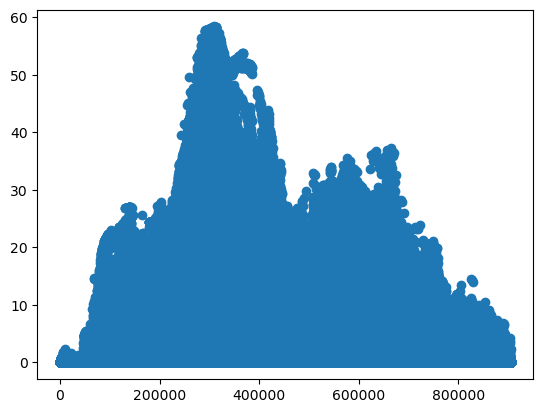

In [28]:
# Create scatter plots of data
x = np.arange(len(non_zero_difference_data))

plt.scatter(x, non_zero_difference_data)

Text(0.5, 1.0, 'Boxplot of Difference Values')

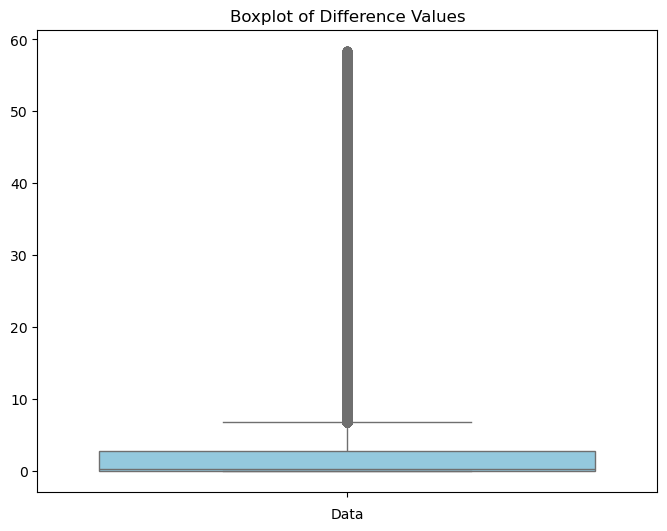

In [27]:
# Create boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=non_zero_difference_data, color='skyblue')

# Adding labels and title
plt.xlabel('Data')
plt.title('Boxplot of Difference Values')


Looking at cross validation results and running statistics

In [22]:
# Load the CSV file into a DataFrame
df = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_12_28_23_updated')

# Drop the first column by index (0)
df = df.drop(df.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df['difference'] = df['observed'] - df['analysis']

# Make a list of just UMRB Stations
UMRB_df = df[df['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df = df[~df['site_ids'].isin(UMRB_ID)]


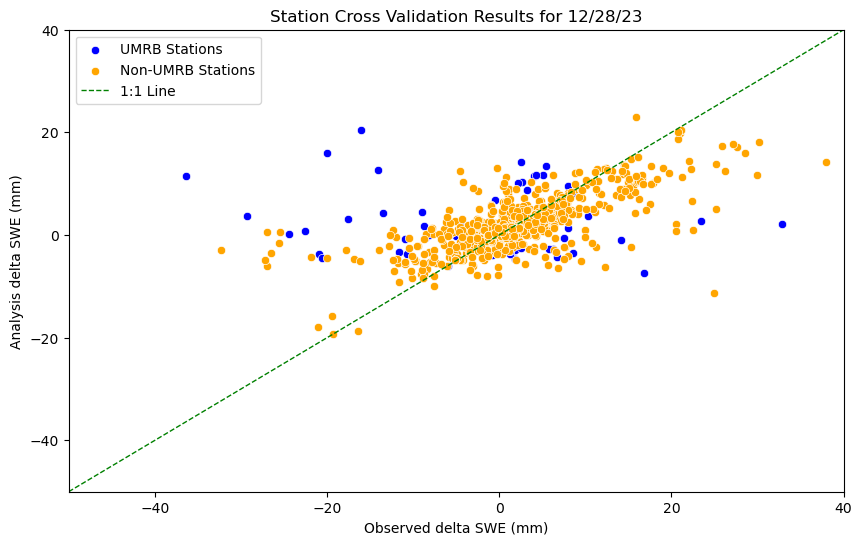

In [23]:
# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Add titles and labels
plt.title('Station Cross Validation Results for 12/28/23')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-50, 40)
plt.ylim(-50, 40)

# Set ticks in increments of 20 starting from -40
plt.xticks(range(-40, 41, 20))
plt.yticks(range(-40, 41, 20))

# Add 1-to-1 line
plt.plot(range(-50, 41), range(-50, 41), color='green', linestyle='--', linewidth=1, label='1:1 Line')

# Show legend
plt.legend()

# Display the plot
plt.show()

In [17]:
# Load the CSV file into a DataFrame
df_2 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_01_10_24')

# Drop the first column by index (0)
df_2 = df_2.drop(df_2.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df_2['difference'] = df_2['observed'] - df_2['analysis']

# Make a list of just UMRB Stations
UMRB_df_2 = df_2[df_2['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df_2 = df_2[~df_2['site_ids'].isin(UMRB_ID)]

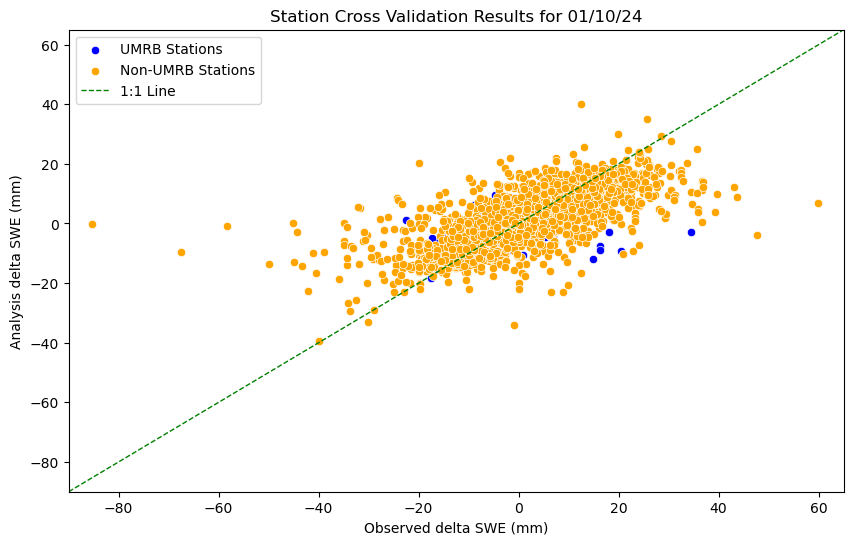

In [21]:
# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df_2, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df_2, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Add titles and labels
plt.title('Station Cross Validation Results for 01/10/24')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-90, 65)
plt.ylim(-90, 65)

# Set ticks in increments of 20 starting from -80
plt.xticks(range(-80, 66, 20))
plt.yticks(range(-80, 66, 20))

# Add 1-to-1 line
plt.plot(range(-90, 66), range(-90, 66), color='green', linestyle='--', linewidth=1, label='1:1 Line')


# Show legend
plt.legend()

# Display the plot
plt.show()

In [18]:
# Load the CSV file into a DataFrame
df_3 = pd.read_csv(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\Cross_Validation_Results\cross_val_12_11_22')

# Drop the first column by index (0)
df_3 = df_3.drop(df_3.columns[0], axis=1)

# Calculate the difference between observed and analysis values
df_3['difference'] = df_3['observed'] - df_3['analysis']

# Make a list of just UMRB Stations
UMRB_df_3 = df_3[df_3['site_ids'].isin(UMRB_ID)]

# Make a list of all other stations
non_UMRB_df_3 = df_3[~df_3['site_ids'].isin(UMRB_ID)]

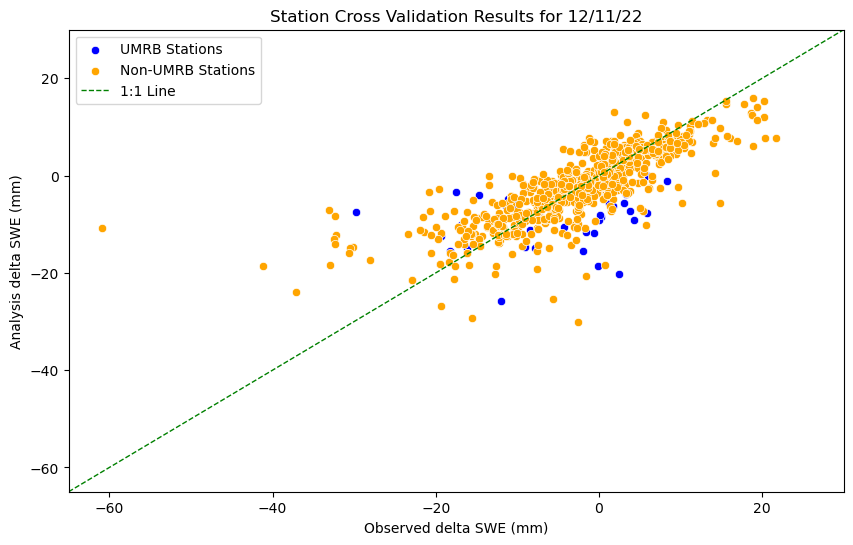

In [23]:
# Create the scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot for UMRB stations
sns.scatterplot(data=UMRB_df_3, x='observed', y='analysis', color='blue', label='UMRB Stations')

# Scatter plot for non-UMRB stations
sns.scatterplot(data=non_UMRB_df_3, x='observed', y='analysis', color='orange', label='Non-UMRB Stations')

# Add titles and labels
plt.title('Station Cross Validation Results for 12/11/22')
plt.xlabel('Observed delta SWE (mm)')
plt.ylabel('Analysis delta SWE (mm)')

# Set x and y axis limits
plt.xlim(-65, 30)
plt.ylim(-65, 30)

# Set ticks in increments of 20 starting from -60
plt.xticks(range(-60, 31, 20))
plt.yticks(range(-60, 31, 20))

# Add 1-to-1 line
plt.plot(range(-90, 66), range(-90, 66), color='green', linestyle='--', linewidth=1, label='1:1 Line')


# Show legend
plt.legend()

# Display the plot
plt.show()